# Medical Insurance Cost Analysis and Prediction

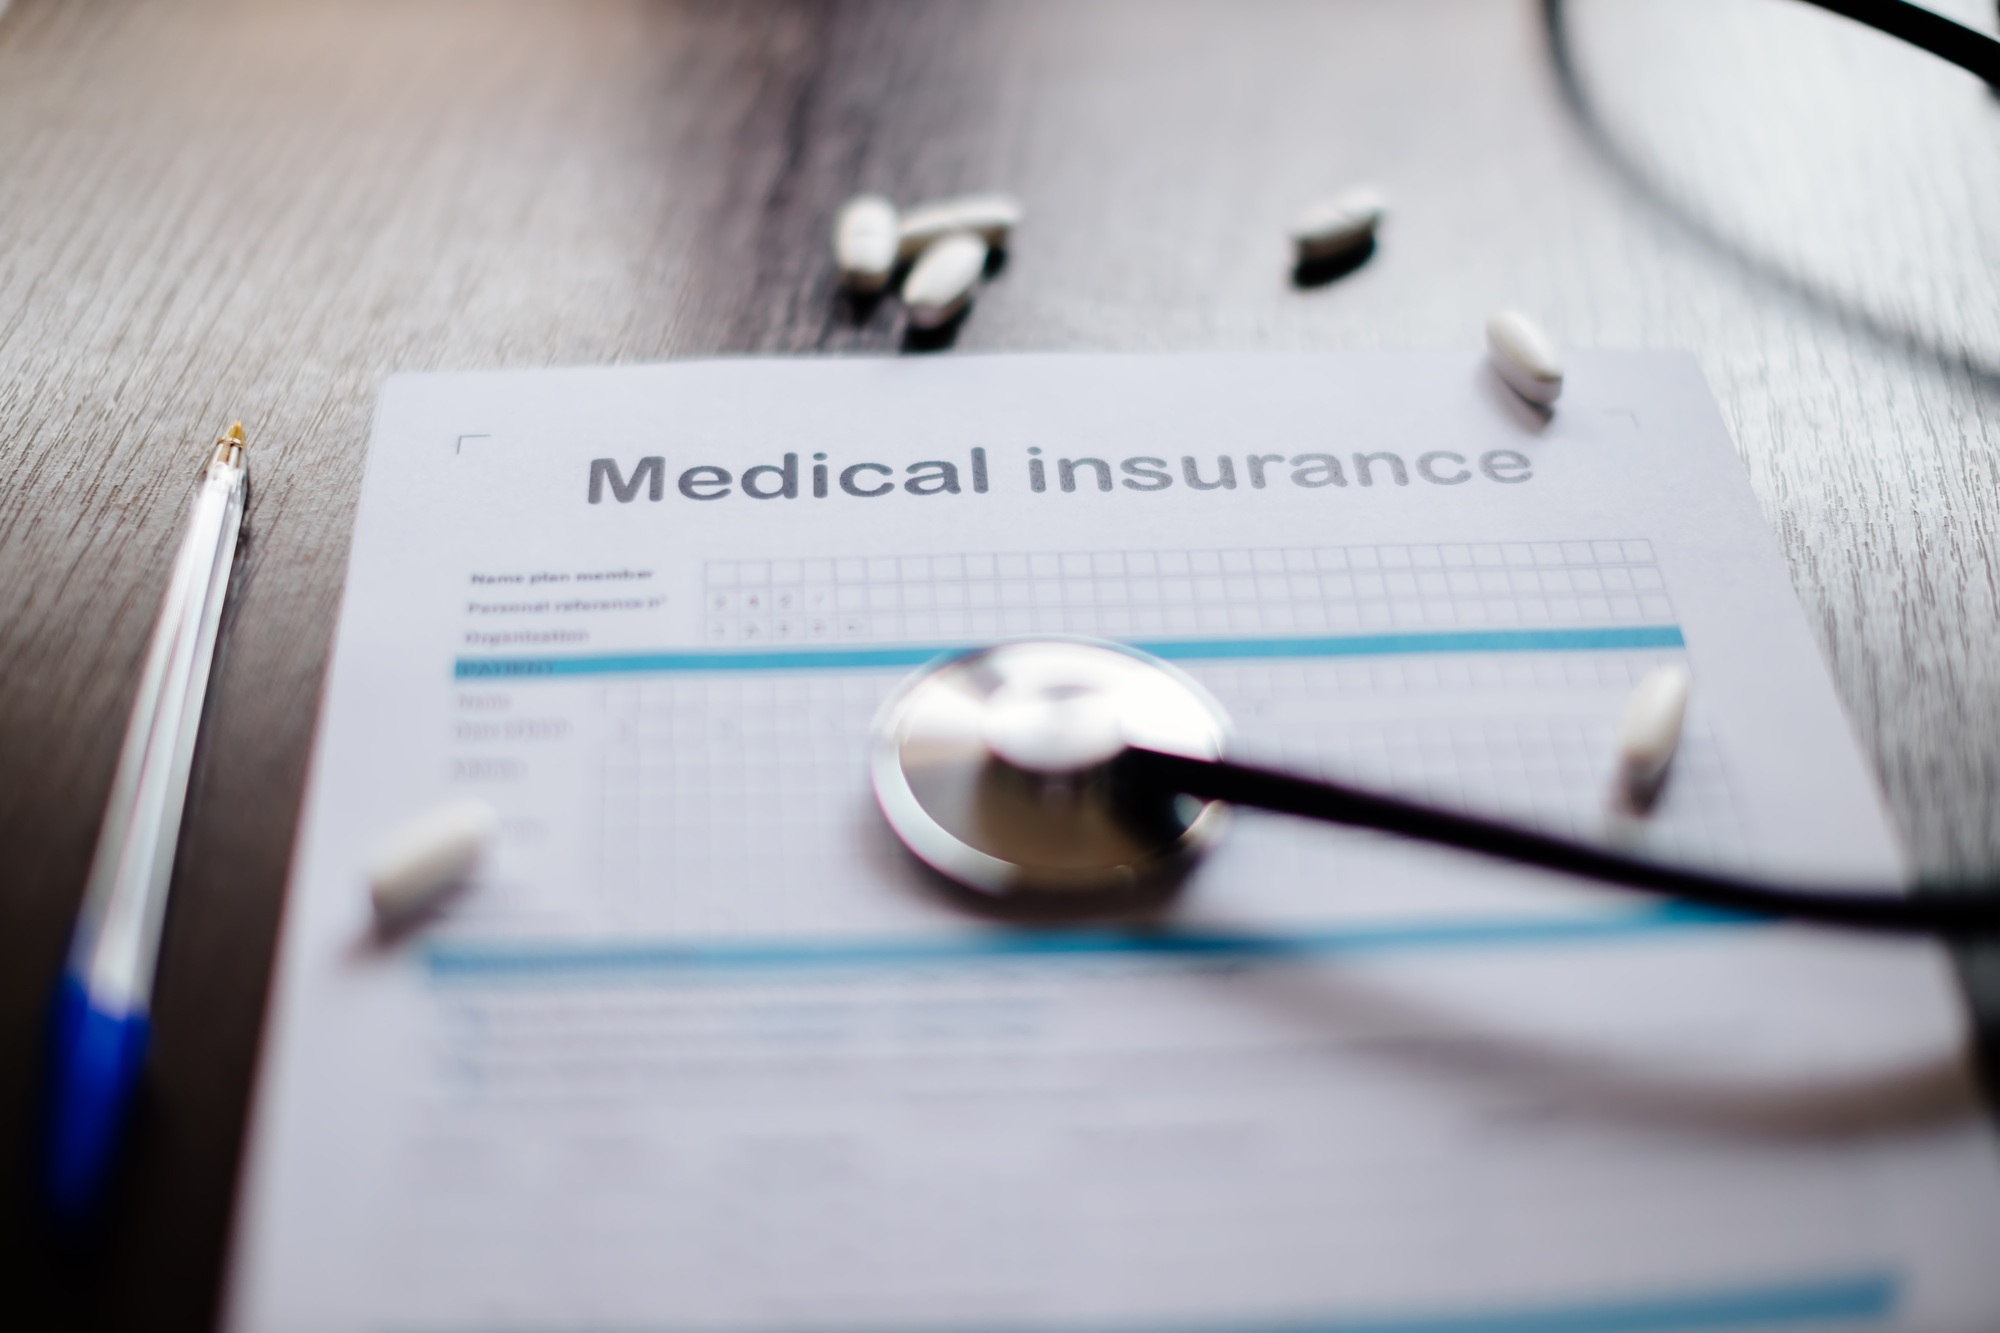

###  Executive Summary

This project investigates the key factors that influence individual medical insurance charges using a dataset containing demographic and health-related attributes such as age, BMI, smoking status, number of children, gender, and residential region.

Exploratory Data Analysis (EDA) revealed several important patterns within the dataset. Insurance charges exhibit a strong right-skewed distribution, indicating that while most individuals incur relatively moderate costs, a smaller group experiences significantly higher medical expenses. The analysis also showed that age and BMI have positive relationships with insurance charges, while smoking status emerged as the most influential categorical factor, with smokers incurring substantially higher medical costs than non-smokers.

Based on insights from the EDA, several engineered features were created to better capture nonlinear relationships and interaction effects in the data. These included a nonlinear age term (`age_squared`), an obesity indicator derived from BMI, and interaction features such as `age_smoker` and `bmi_smoker` to represent how smoking amplifies health risks associated with age and body mass index.

Multiple machine learning models were evaluated to predict insurance charges, including Linear Regression, Random Forest, and XGBoost. Feature engineering improved model performance across several algorithms. Among the evaluated models, a tuned Random Forest regressor achieved the best predictive performance, explaining approximately **89.8% of the variance in medical charges (R² ≈ 0.898)** with an average prediction error of roughly **$1,937 (MAE)**.

Feature importance analysis from the final model revealed that **age, nonlinear age effects, smoking status, and interactions between smoking and BMI or age** are the dominant drivers of insurance costs. In contrast, features such as gender and geographic region contributed minimally to the model’s predictions.

Overall, this project demonstrates how careful exploratory analysis, targeted feature engineering, and ensemble machine learning methods can effectively model complex healthcare cost patterns while also providing interpretable insights into the primary factors influencing medical insurance charges.


### Data Overview

In [22]:
# Import dependencies
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Import data
data = pd.read_csv('data/insurance.csv')
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [24]:
# Properties of the data
print(f'\n information of the data: \n {data.info()}')
print(f'\n shape of the data: {data.shape}')
print(f'\n statistical summary of the data: \n {data.describe()}')
print(f'\n checking for missing values: \n {data.isnull().sum()}')
print(f'\n checking for duplicate values: \n {data.duplicated().sum()}')

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB

 information of the data: 
 None

 shape of the data: (1338, 7)

 statistical summary of the data: 
                age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.0

In [25]:
# Check for where duplicates are
duplicate_rows = data[data.duplicated(keep=False)]
duplicate_rows

,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


In [26]:
# Cleaning the data by removing duplicates
data = data.drop_duplicates()
print(f'New shape of the data after removing duplicates: {data.shape}')
# Verify duplicates are removed
print(f'checking for duplicate values after cleaning: \n {data.duplicated().sum()}')

New shape of the data after removing duplicates: (1337, 7)
checking for duplicate values after cleaning: 
 0


In [27]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### EDA

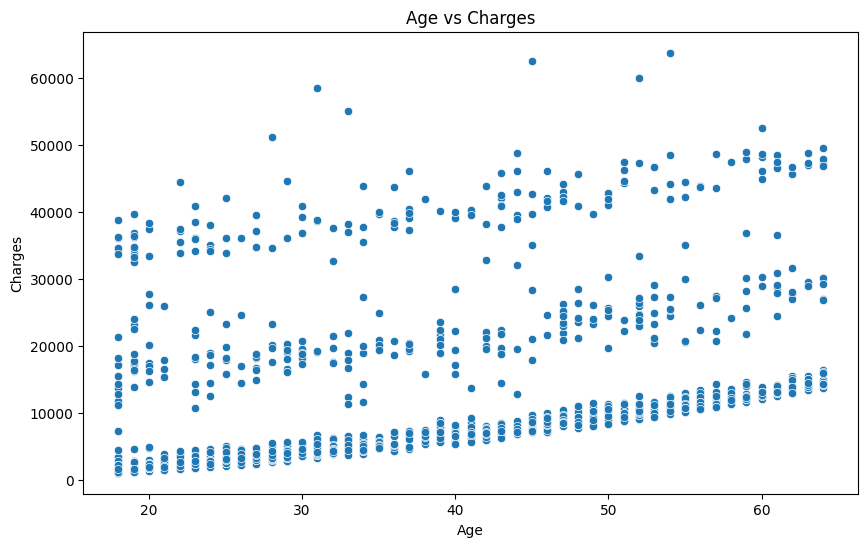

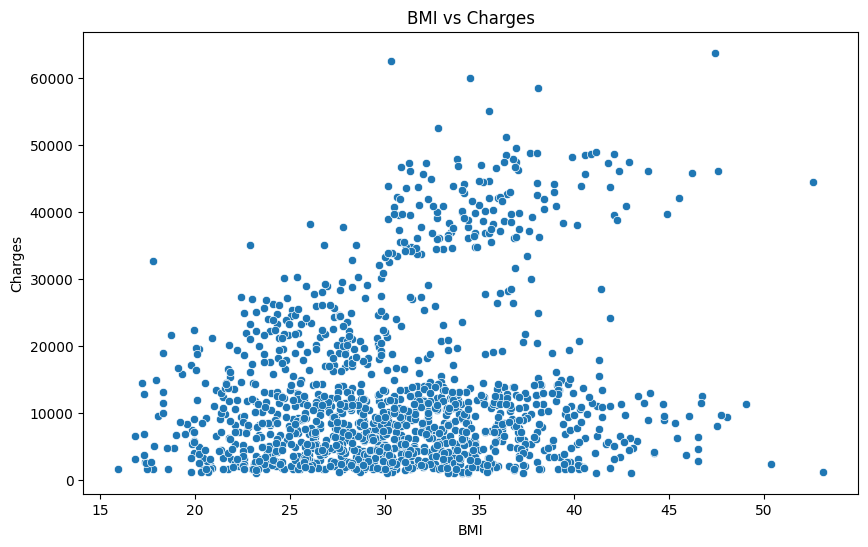

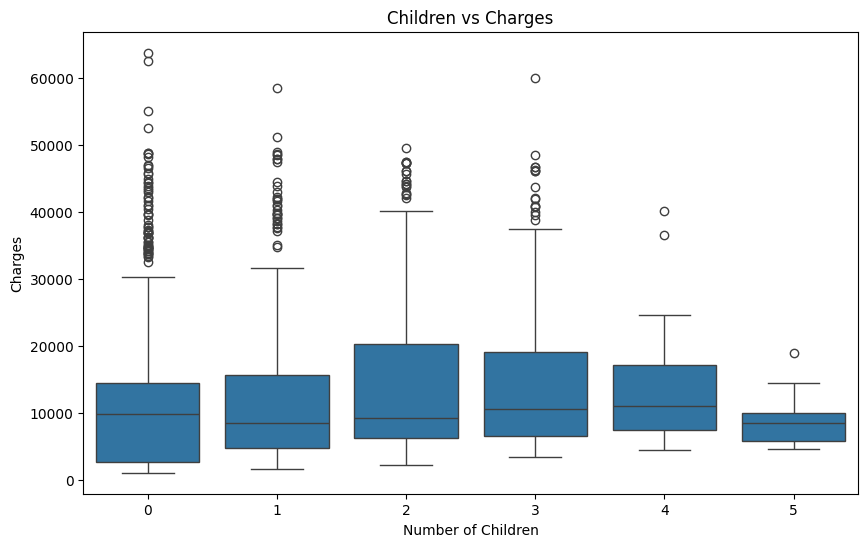

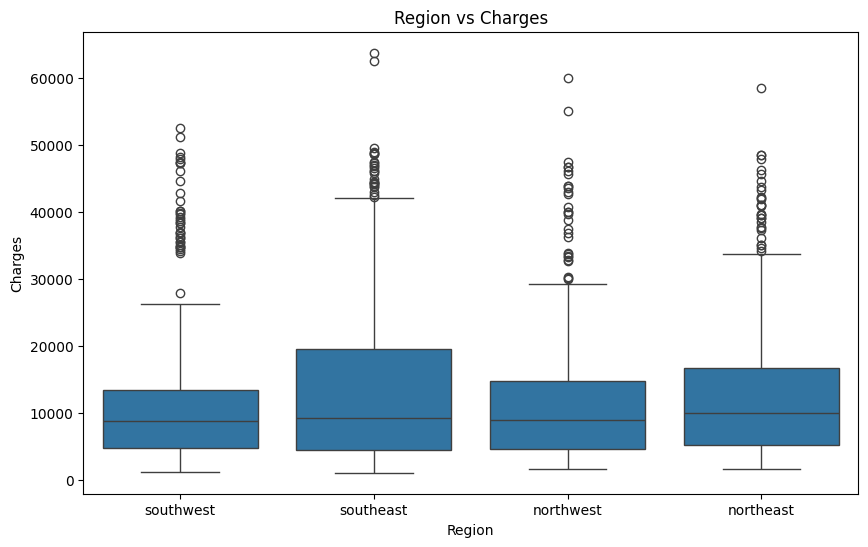

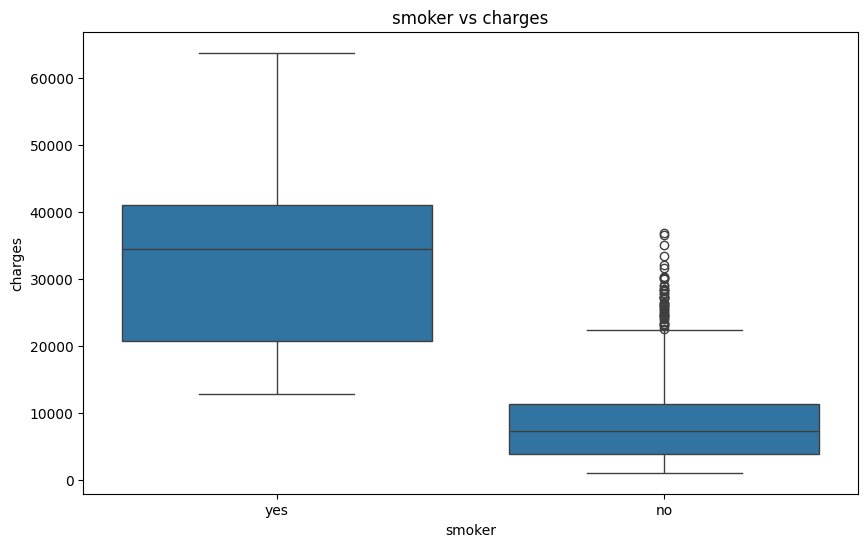

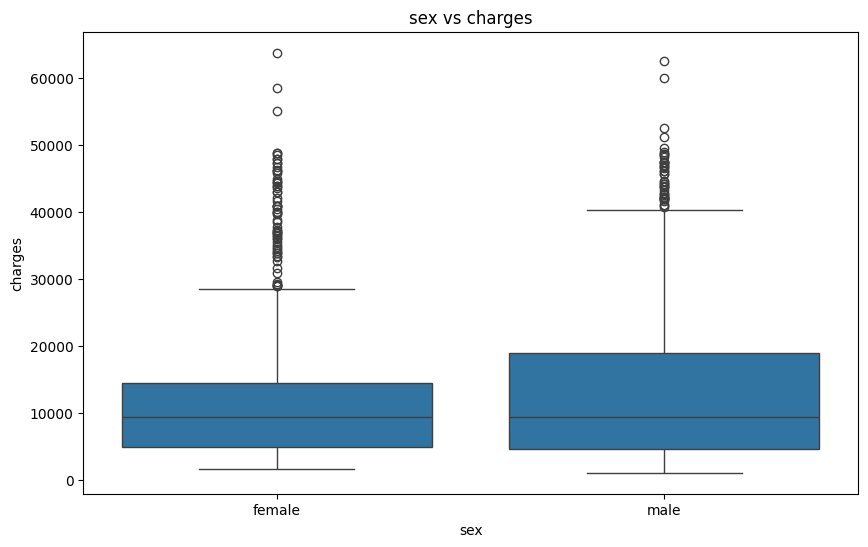

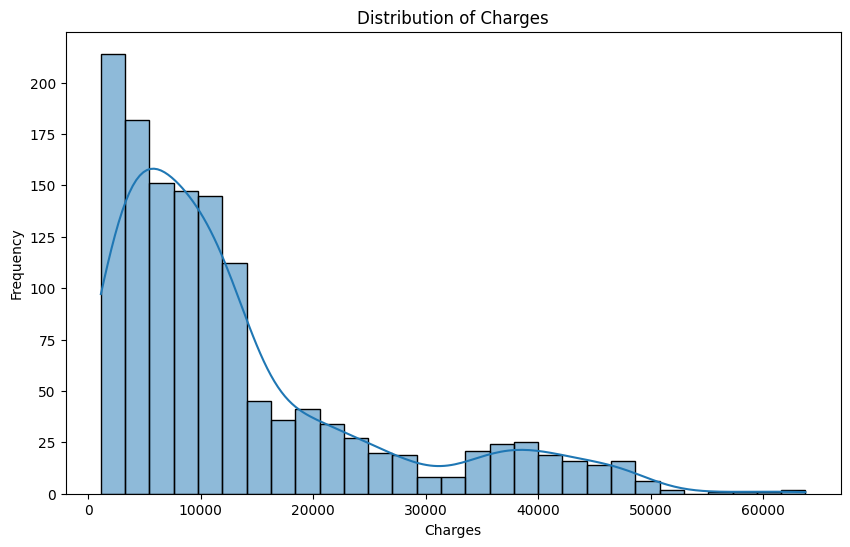

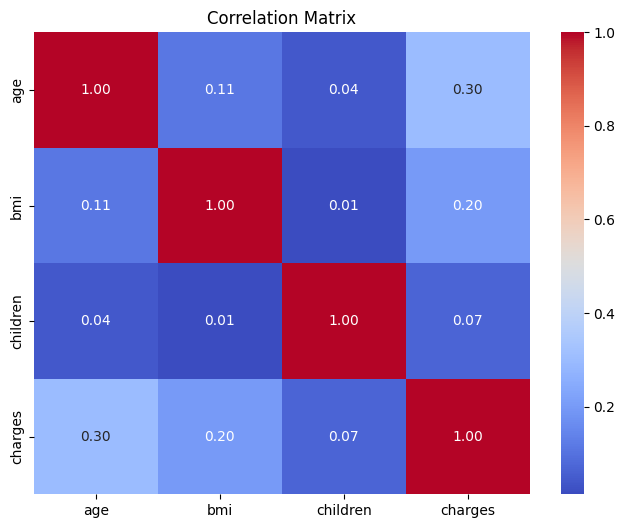

In [28]:
# checking the influence of age on charges
plt.figure(figsize=(10,6))
sns.scatterplot(x='age', y='charges', data=data)
plt.title('Age vs Charges')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.show()

# checking the influence of bmi on charges
plt.figure(figsize=(10,6))
sns.scatterplot(x='bmi', y='charges', data=data)
plt.title('BMI vs Charges')
plt.xlabel('BMI')
plt.ylabel('Charges')
plt.show()

# checking the influence of children on charges
plt.figure(figsize=(10,6))
sns.boxplot(x='children', y='charges', data=data)
plt.title('Children vs Charges')
plt.xlabel('Number of Children')
plt.ylabel('Charges')
plt.show()

# checking the influence of region on charges
plt.figure(figsize=(10,6))
sns.boxplot(x='region', y='charges', data=data)
plt.title('Region vs Charges')
plt.xlabel('Region')
plt.ylabel('Charges')
plt.show()

# Checking the influence of smoking on charges
plt.figure(figsize=(10,6))
sns.boxplot(x='smoker', y='charges', data=data)
plt.title('smoker vs charges')
plt.xlabel('smoker')
plt.ylabel('charges')
plt.show()

# Checking the influence of sex on charges
plt.figure(figsize=(10,6))
sns.boxplot(x='sex', y='charges', data=data)
plt.title('sex vs charges')
plt.xlabel('sex')
plt.ylabel('charges')
plt.show()

# Checking for target variable distribution
plt.figure(figsize=(10,6))
sns.histplot(data['charges'], kde=True)
plt.title('Distribution of Charges')
plt.xlabel('Charges')
plt.ylabel('Frequency')
plt.show()

# Checking the correlation between numerical features and charges
numerical_features = ['age', 'bmi', 'children', 'charges']
correlation_matrix = data[numerical_features].corr()
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()


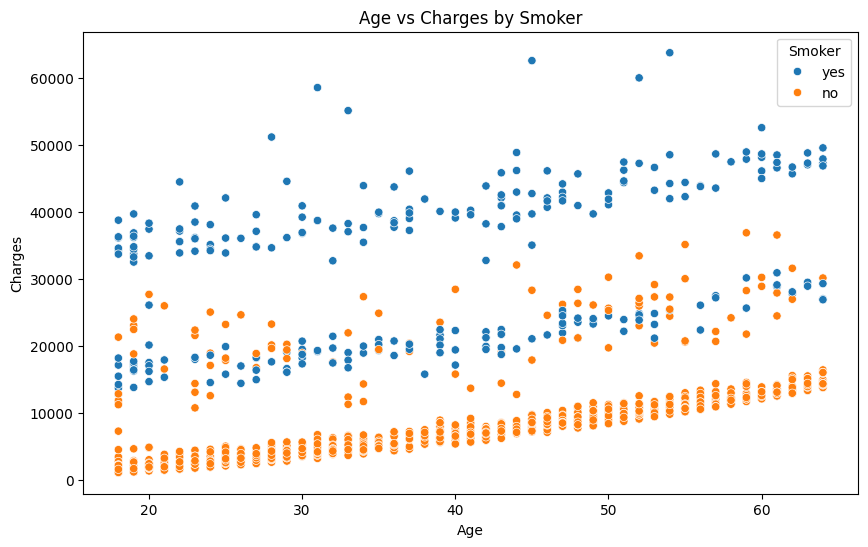

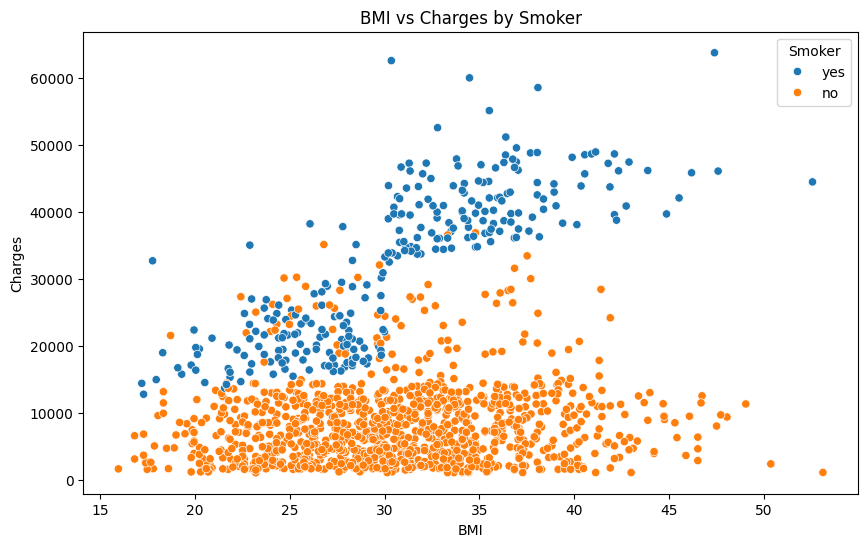

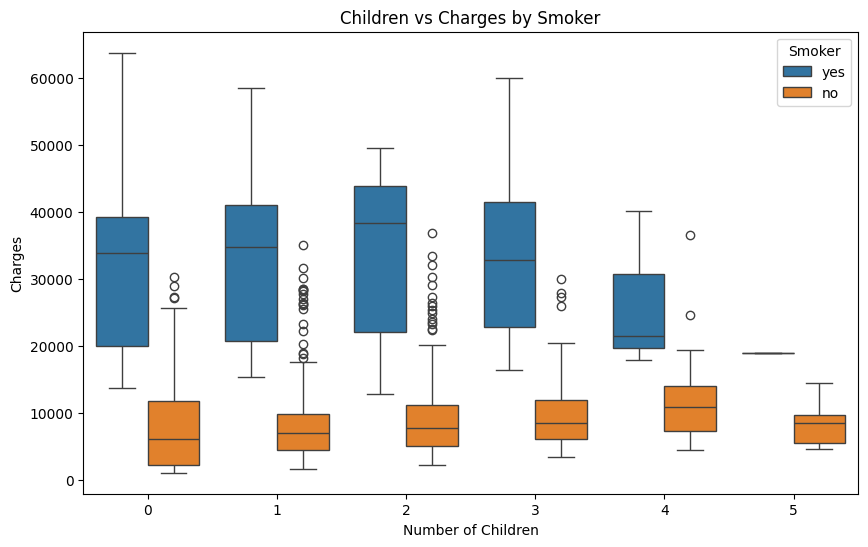

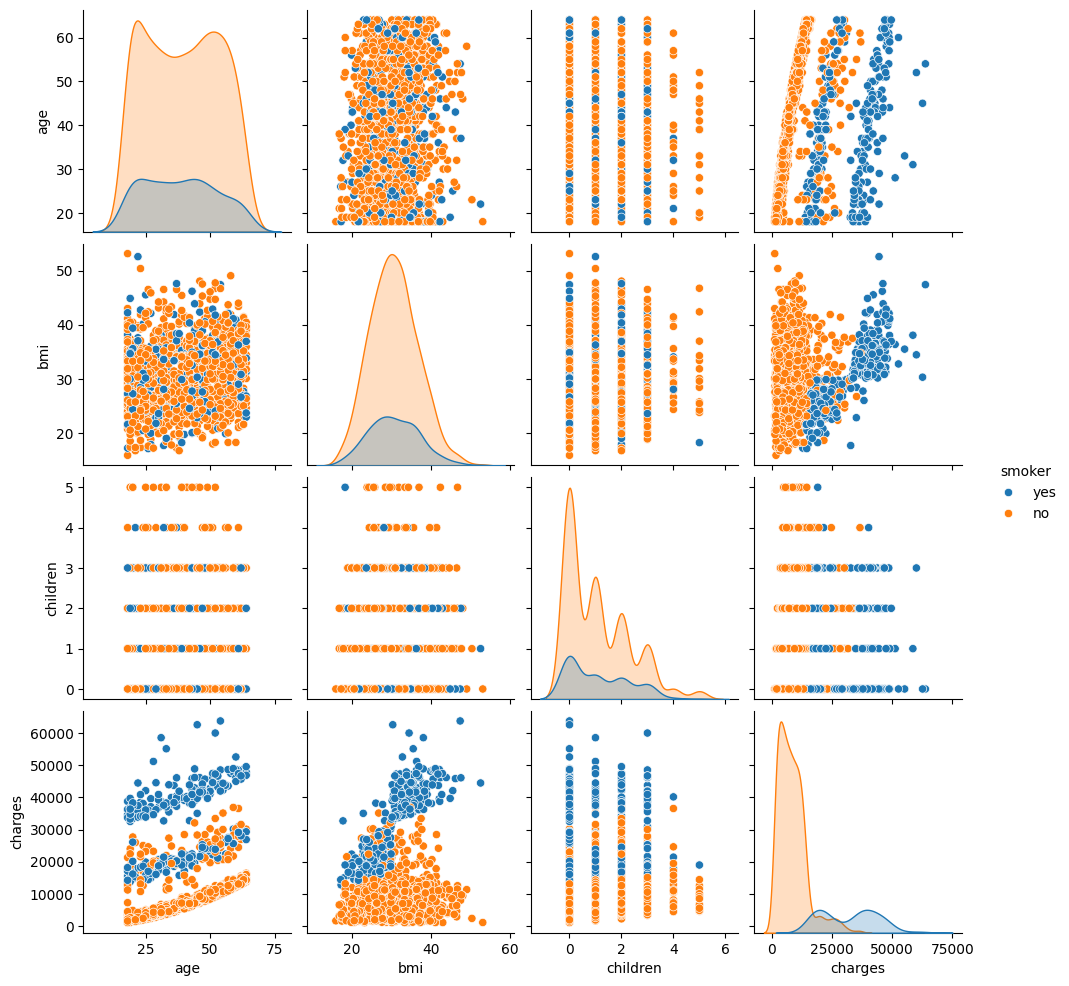

In [29]:
# Checking the Smoker interaction analysis

# Age vs Charges by Smoker
plt.figure(figsize=(10,6))
sns.scatterplot(x='age', y='charges', hue='smoker', data=data)
plt.title('Age vs Charges by Smoker')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.legend(title='Smoker')
plt.show()

# BMI vs Charges by Smoker
plt.figure(figsize=(10,6))
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=data)
plt.title('BMI vs Charges by Smoker')
plt.xlabel('BMI')
plt.ylabel('Charges')
plt.legend(title='Smoker')
plt.show()

# Children vs Charges by Smoker
plt.figure(figsize=(10,6))
sns.boxplot(x='children', y='charges', hue='smoker', data=data)
plt.title('Children vs Charges by Smoker')
plt.xlabel('Number of Children')
plt.ylabel('Charges')
plt.legend(title='Smoker')
plt.show()

# Pairplot to check interactions between features
sns.pairplot(data, hue='smoker')

In [30]:
# Grouped statistics table

eda_data = data.copy()

# Mean charges per smoker status
mean_charges_smoker = eda_data.groupby('smoker')['charges'].mean().reset_index()
print(f'Mean Charges by Smoker Status: \n \n{mean_charges_smoker}')

# Mean charges per age band
eda_data['age_band'] = pd.cut(eda_data['age'], bins=[0, 18, 30, 45, 60, 100], labels=['0-18', '19-30', '31-45', '46-60', '61+'])
mean_charges_age_band = eda_data.groupby('age_band')['charges'].mean().reset_index()
print(f'\n Mean Charges by Age Band: \n \n{mean_charges_age_band}')

# Mean charges per BMI category
eda_data['bmi_category'] = pd.cut(eda_data['bmi'], bins=[0, 18.5, 25, 30, 100], labels=['Underweight', 'Normal', 'Overweight', 'Obese'])
mean_charges_bmi_category = eda_data.groupby('bmi_category')['charges'].mean().reset_index()
print(f'\n Mean Charges by BMI Category: \n \n{mean_charges_bmi_category}')

Mean Charges by Smoker Status: 
 
  smoker       charges
0     no   8440.660307
1    yes  32050.231832

 Mean Charges by Age Band: 
 
  age_band       charges
0     0-18   7086.217556
1    19-30   9844.718012
2    31-45  12647.455654
3    46-60  16340.993846
4      61+  21063.163398

 Mean Charges by BMI Category: 
 
  bmi_category       charges
0  Underweight   8657.620652
1       Normal  10435.440719
2   Overweight  10997.803881
3        Obese  15580.700985



Distribution of sex:
sex
male      50.486163
female    49.513837
Name: proportion, dtype: float64


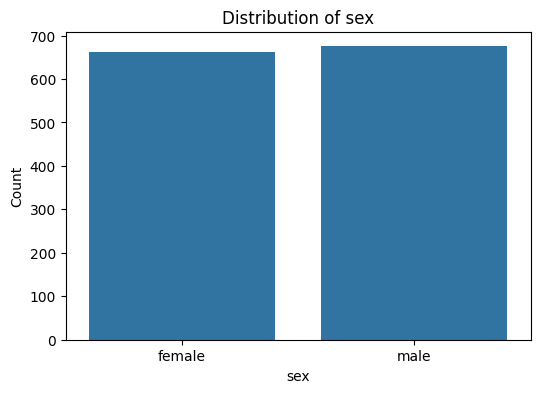


Distribution of smoker:
smoker
no     79.506358
yes    20.493642
Name: proportion, dtype: float64


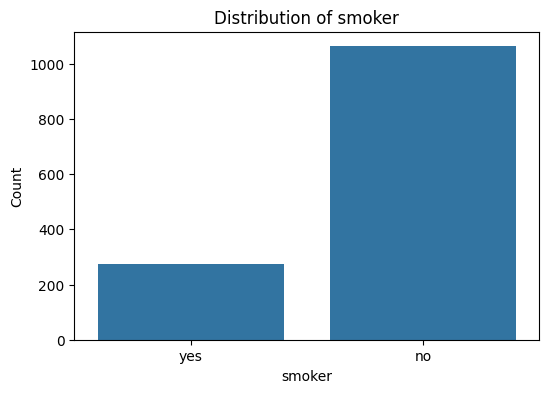


Distribution of region:
region
southeast    27.225131
southwest    24.308153
northwest    24.233358
northeast    24.233358
Name: proportion, dtype: float64


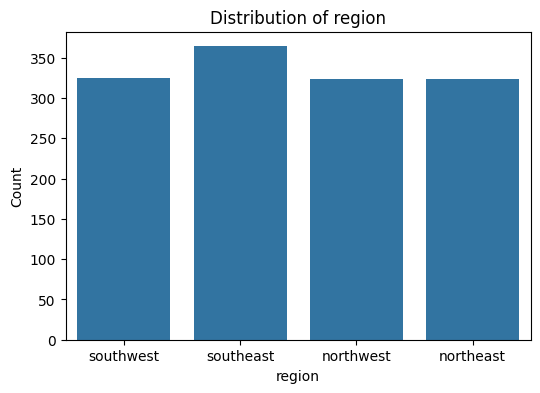

In [31]:
# Check Data Balance (Categorical % Distribution) 
categorical_features = ['sex', 'smoker', 'region']
for feature in categorical_features:
    distribution = data[feature].value_counts(normalize=True) * 100
    print(f'\nDistribution of {feature}:\n{distribution}')

    plt.figure(figsize=(6,4))
    sns.countplot(x=feature, data=data)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.show()
    


### Objective

The objective of this exploratory data analysis is to understand the structure of the dataset and investigate how each independent variable influences the target variable, charges. This analysis helps guide feature engineering decisions and model selection.

* The target variable:

- Charges - Medical insurance cost (continuous numerical variable)

* The independent variables:

- Age

- BMI

- Children

- Smoker

- Sex

- Region


#### 1. Target Variable Distribution

The distribution of charges is highly right-skewed.

##### * Observations:

Most individuals incur low-to-moderate charges.

A smaller group incurs very high costs (long right tail).

The distribution is not normal.

A secondary peak appears in the higher range.

##### * Interpretation:

The skewness indicates the presence of extreme high-cost individuals, likely associated with smoking status. This suggests that a log transformation of the target may improve linear model performance and stabilize variance.


#### 2. Smoking Status and Charges

The box plot and grouped statistics show a strong separation between smokers and non-smokers.

##### * Key Statistics:

Mean charges (Non-smoker): ~8,440

Mean charges (Smoker): ~32,050

##### * Observations:

Minimal overlap between the two groups.

Smokers consistently have significantly higher costs.

Smokers exhibit greater variability in charges.

##### * Interpretation:

Smoking status is the dominant predictor of insurance charges. It creates two distinct cost populations within the dataset.


#### 3. Age and Charges

The scatter plot of age versus charges shows a clear positive relationship.

##### * Observations:

Charges increase with age.

Variance increases at higher ages (heteroscedasticity).

Distinct cost bands appear when colored by smoker.

##### * Interpretation:

Age strongly influences insurance charges. Additionally, the increasing variance suggests that older individuals have more unpredictable medical expenses. The separation by smoking status indicates an interaction effect between age and smoker.


#### 4. BMI and Charges

BMI demonstrates a moderate positive relationship with charges.

##### * Observations:

Charges generally increase with BMI.

Smokers with high BMI incur extremely high charges.

BMI effect is more pronounced among smokers.

##### * Interpretation:

BMI contributes moderately to insurance costs. However, its impact is significantly amplified for smokers, suggesting a meaningful interaction effect.


#### 5. Number of Children and Charges

The relationship between number of children and charges appears weak.

##### * Observations:

Slight increase in median charges up to 3–4 children.

Heavy overlap across groups.

Smoking status dominates within each group.

##### * Interpretation:

The number of children has minimal predictive power compared to smoking and age.


#### 6. Region and Charges

Regional comparisons show little variation in charges.

##### * Observations:

Similar medians across all regions.

Significant overlap.

Outliers present in every region.

##### * Interpretation:

Geographic region has negligible influence on insurance charges in this dataset.



#### 7. Sex and Charges

The distribution of charges by sex shows minimal difference.

##### * Observations:

Nearly identical medians.

Heavy overlap.

Balanced representation (~50/50 split).

##### * Interpretation:

Sex does not significantly affect insurance charges.



#### 8. Correlation Analysis

The Pearson correlation matrix for numerical features shows:

- Age ↔ Charges: 0.30 (moderate)

- BMI ↔ Charges: 0.20 (weak–moderate)

- Children ↔ Charges: 0.07 (weak)

- No strong multicollinearity exists among predictors.

##### * Interpretation:

Age is the strongest linear numerical predictor of charges. However, correlation analysis does not capture the strong effect of categorical variables such as smoking.




#### Overall Insights

From the complete exploratory analysis:

Smoking status is the strongest determinant of insurance charges.

Age has a strong positive relationship with charges.

BMI has a moderate effect, particularly among smokers.

Children, region, and sex have minimal influence.

The target variable is right-skewed and exhibits heteroscedasticity.

Interaction effects (especially smoker × age and smoker × BMI) are likely important.



#### Conclusion

The dataset demonstrates clear structural patterns rather than random variation. Insurance charges are primarily driven by health-related risk factors, especially smoking behavior and age.

These findings inform the next step of the workflow: feature engineering, where interaction terms and potential target transformations will be explored to improve predictive modeling performance.


In [32]:
# Saving the cleaned data for modeling
data.to_csv('cleaned_insurance_data.csv', index=False)